# EDA: AI Tool Usage and Academic Performance

Exploratory data analysis of the *AI Student Impact Dataset* (50 000 students).
Key question: **how does GenAI usage relate to GPA change and student well-being?**

In [1]:
%pip install -q statsmodels seaborn scipy scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ── Global visual style ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 100})

C_PRIMARY = "#2b5c8f"   # steel blue  — scatter points, bars
C_LIGHT   = "#93b8d4"   # sky blue    — confidence bands, fills
C_ACCENT  = "#c0392b"   # red         — regression lines, reference lines
C_MID     = "#6b7280"   # slate gray  — neutral guides

## 1. Data Overview

In [2]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
df.describe()

NameError: name 'df' is not defined

In [3]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [4]:
df.nunique().to_frame('unique_values')

,unique_values
Student_ID,50000
Major_Category,5
Year_of_Study,5
Pre_Semester_GPA,2389
Weekly_GenAI_Hours,3566
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Tool_Diversity,5
Paid_Subscription,2
Traditional_Study_Hours,2516


## 2. Feature Engineering

`GPA_change = Post_Semester_GPA - Pre_Semester_GPA` captures whether a student's GPA improved during the semester.

In [5]:
df['GPA_change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

In [6]:
df['GPA_change'].describe().to_frame()

,GPA_change
count,50000.000000
mean,0.203197
std,0.187192
min,-0.924000
25%,0.087000
50%,0.204000
75%,0.325000
max,1.008000


## 3. Distributions

findfont: Failed to find font weight semibold, now using 700.


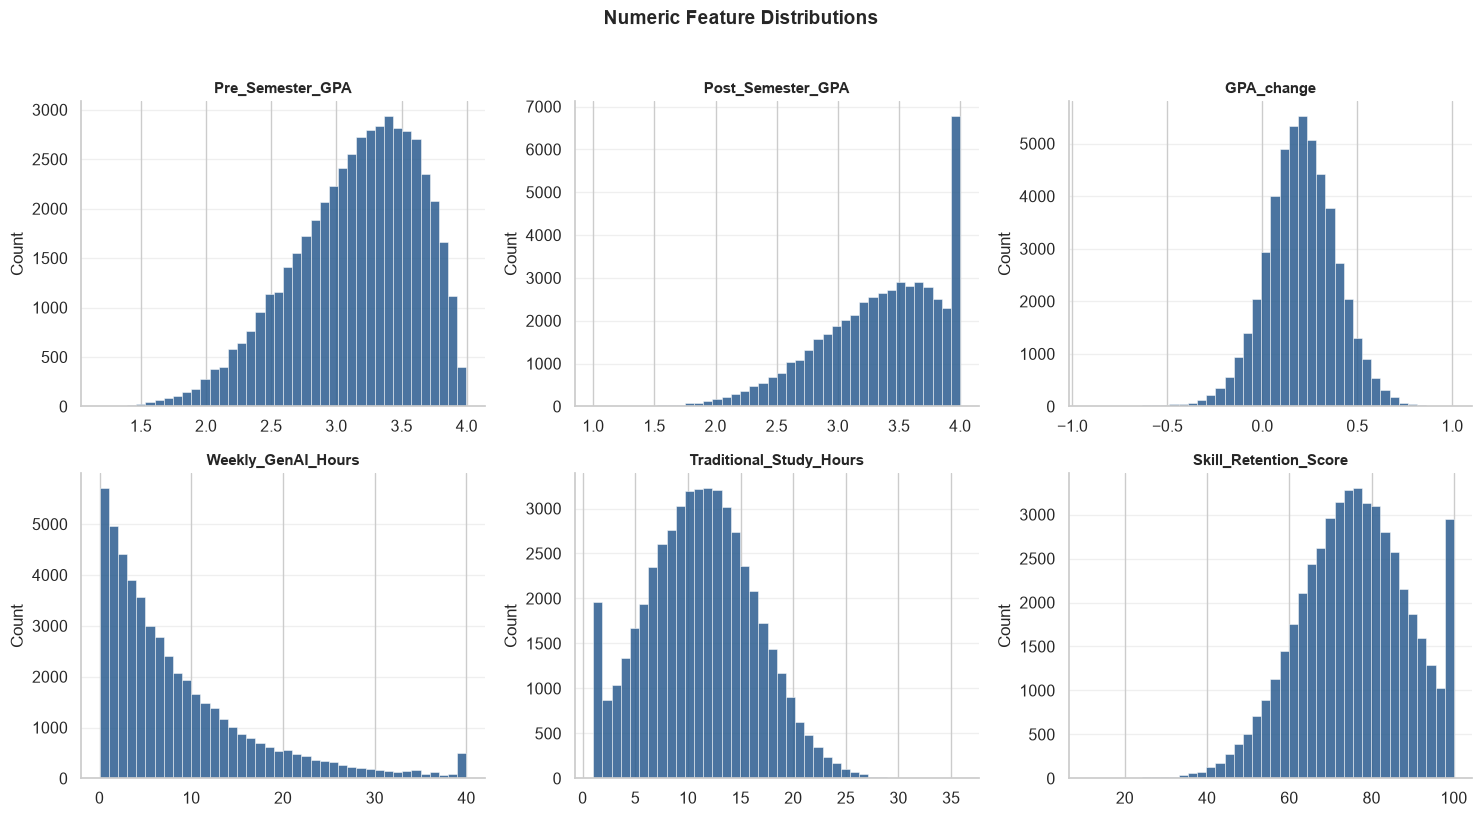

In [7]:
numeric_cols = [
    'Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_change',
    'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color=C_PRIMARY, alpha=0.85,
                 edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=11, fontweight='semibold')
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].spines[['top', 'right']].set_visible(False)

fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

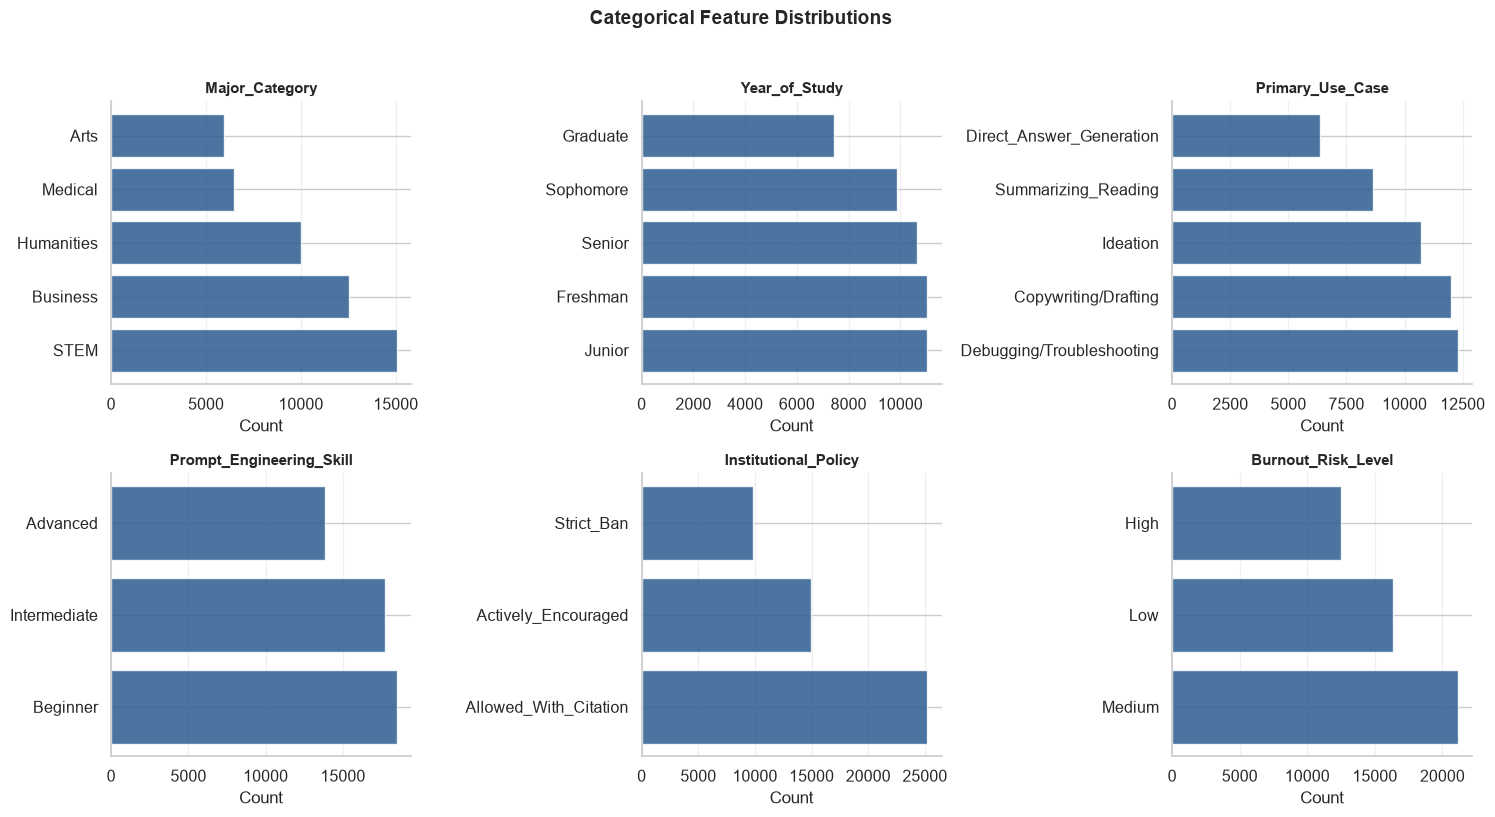

In [ ]:
cat_cols = [
    'Major_Category', 'Year_of_Study', 'Primary_Use_Case',
    'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=C_PRIMARY, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='semibold')
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].spines[['top', 'right']].set_visible(False)

fig.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Matrix

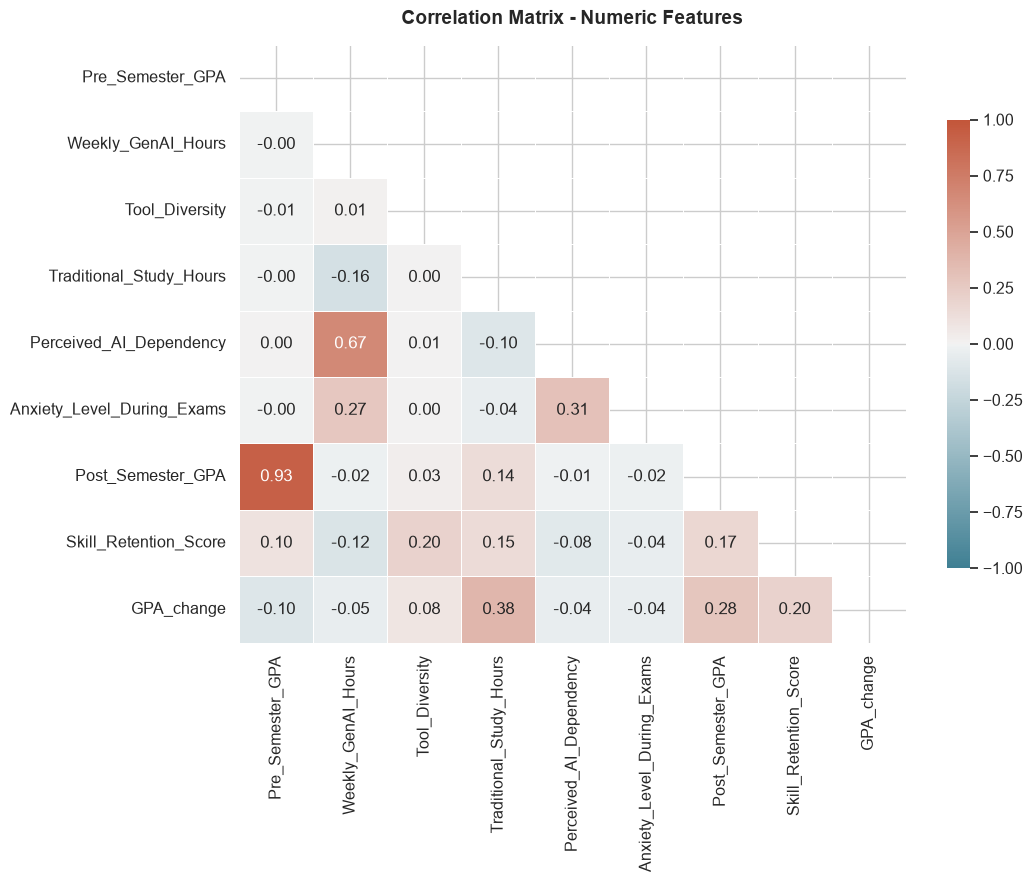

In [163]:
num_df = df.select_dtypes(include='number').drop(columns=['Student_ID'])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, cmap=cmap,
    vmax=1, vmin=-1, center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.75}
)
ax.set_title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 5. GenAI Hours vs GPA Change

Does using GenAI tools more correlate with a larger GPA improvement?

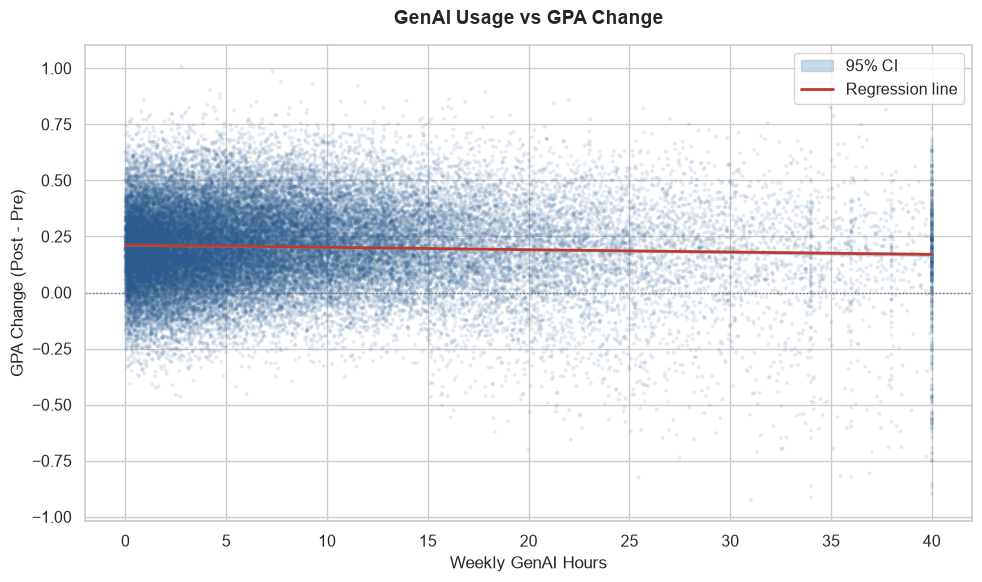

In [164]:
x_vals = df['Weekly_GenAI_Hours'].values
y_vals = df['GPA_change'].values

X_ols = sm.add_constant(x_vals)
ols_fit = sm.OLS(y_vals, X_ols).fit()

x_plot = np.linspace(x_vals.min(), x_vals.max(), 400)
pred = ols_fit.get_prediction(sm.add_constant(x_plot)).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_vals, y_vals, alpha=0.12, color=C_PRIMARY, edgecolor='none', s=8)
ax.fill_between(x_plot, pred['mean_ci_lower'], pred['mean_ci_upper'],
                color=C_LIGHT, alpha=0.5, label='95% CI')
ax.plot(x_plot, pred['mean'], color=C_ACCENT, linewidth=2, label='Regression line')
ax.axhline(0, color=C_MID, linestyle=':', linewidth=1)
ax.set_title('GenAI Usage vs GPA Change', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours')
ax.set_ylabel('GPA Change (Post - Pre)')
ax.legend()
plt.tight_layout()
plt.show()

In [165]:
corr_coef, p_value = stats.pearsonr(df['Weekly_GenAI_Hours'], df['GPA_change'])
mi_score = mutual_info_regression(
    df[['Weekly_GenAI_Hours']], df['GPA_change'], random_state=42
)[0]

print(f"Pearson r   : {corr_coef:.4f}")
print(f"p-value     : {p_value:.2e}")
print(f"Mutual Info : {mi_score:.4f}")

Pearson r   : -0.0465
p-value     : 2.52e-25
Mutual Info : 0.0187


> **Note on significance vs effect size.**
> With n = 50 000 almost any non-zero correlation is statistically significant (p-value -> 0).
> Pearson r = -0.046 explains ~0.2% of variance — the association is real but negligible in practice.
> Mutual Information = 0.019 confirms almost no non-linear signal either.

### Non-linear Trend (LOWESS)

Even with near-zero linear correlation, a non-parametric smoother may reveal a non-monotonic pattern.

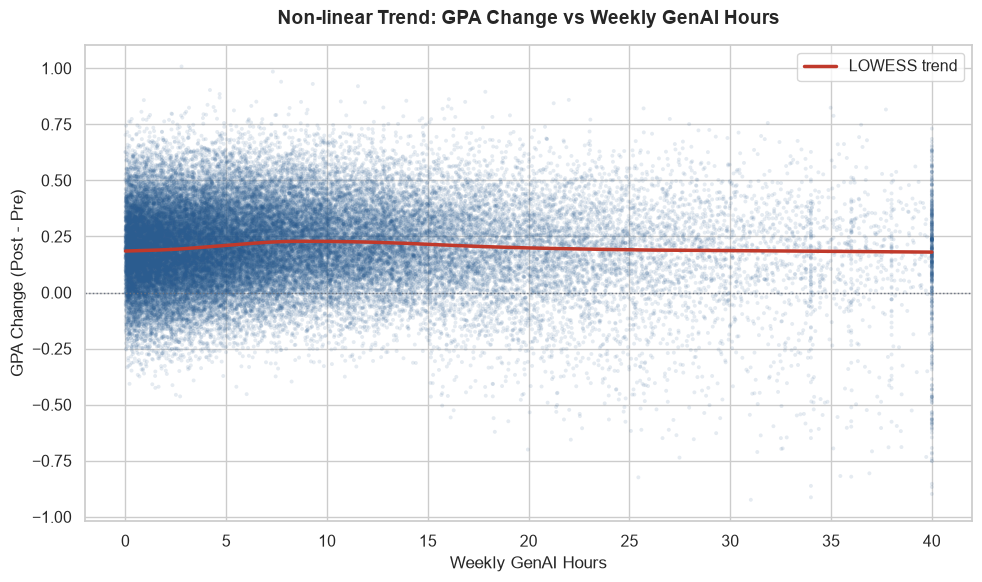

In [166]:
lowess_res = sm_lowess(
    df['GPA_change'], df['Weekly_GenAI_Hours'],
    frac=0.3, delta=0.5
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Weekly_GenAI_Hours'], df['GPA_change'],
           alpha=0.12, color=C_PRIMARY, edgecolor='none', s=8)
ax.plot(lowess_res[:, 0], lowess_res[:, 1],
        color=C_ACCENT, linewidth=2.5, label='LOWESS trend')
ax.axhline(0, color=C_MID, linestyle=':', linewidth=1)
ax.set_title('Non-linear Trend: GPA Change vs Weekly GenAI Hours',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours')
ax.set_ylabel('GPA Change (Post - Pre)')
ax.legend()
plt.tight_layout()
plt.show()

### Distribution by Usage Bins

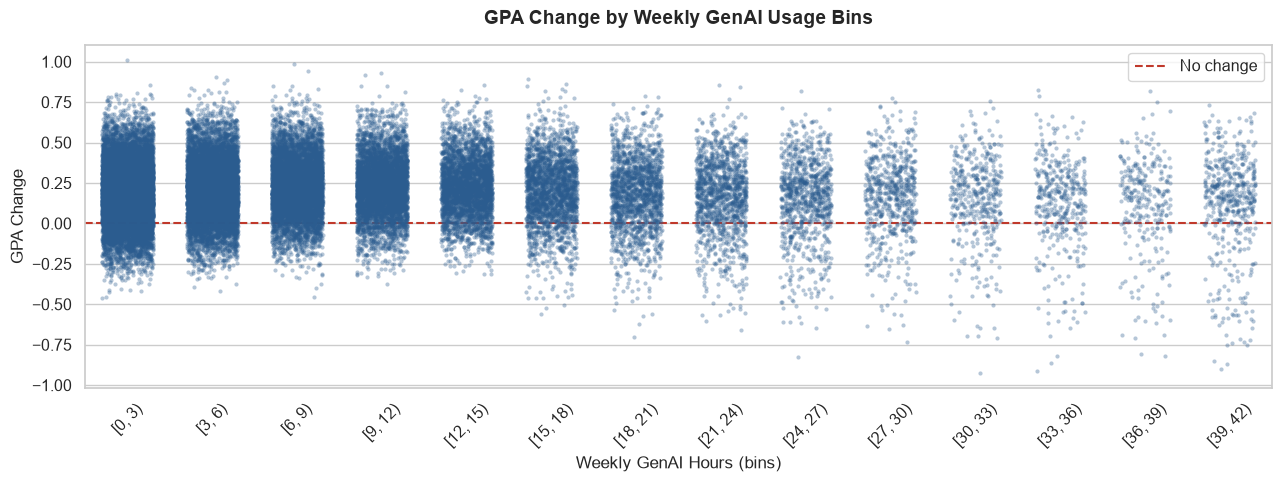

In [167]:
bins = list(range(0, int(df['Weekly_GenAI_Hours'].max()) + 3, 3))
plot_df = df.copy()
plot_df['Hours_Bin'] = pd.cut(df['Weekly_GenAI_Hours'], bins=bins, right=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.stripplot(data=plot_df, x='Hours_Bin', y='GPA_change',
              jitter=0.3, alpha=0.35, color=C_PRIMARY, size=3, ax=ax)
ax.axhline(0, color=C_ACCENT, linestyle='--', linewidth=1.5, label='No change')
ax.set_title('GPA Change by Weekly GenAI Usage Bins',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours (bins)')
ax.set_ylabel('GPA Change')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### Joint Distribution

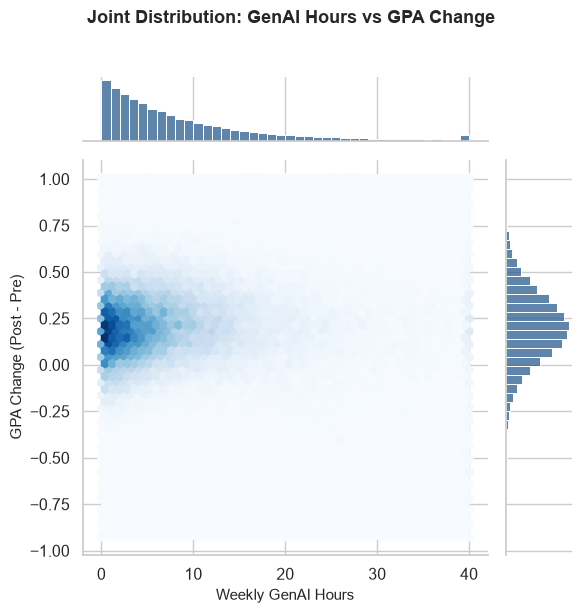

In [168]:
g = sns.jointplot(
    data=df, x='Weekly_GenAI_Hours', y='GPA_change',
    kind='hex', cmap='Blues',
    marginal_kws={'color': C_PRIMARY, 'bins': 40}
)
g.set_axis_labels('Weekly GenAI Hours', 'GPA Change (Post - Pre)', fontsize=11)
g.figure.suptitle('Joint Distribution: GenAI Hours vs GPA Change',
                  y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. K-Means Clustering

K-Means on `Weekly_GenAI_Hours` and `GPA_change` to surface natural groupings.
*Note: with Pearson r ~ -0.05, clusters will mostly segment by hours (X-axis) rather than diagonally.*

In [169]:
X_cluster = df[['Weekly_GenAI_Hours', 'GPA_change']].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
X_cluster['Cluster'] = kmeans.fit_predict(X_scaled)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

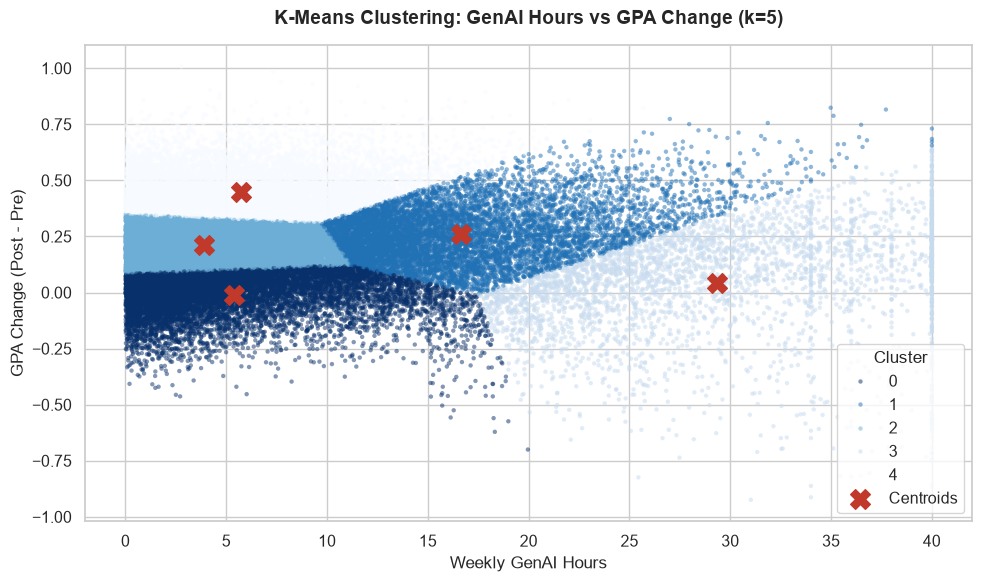

In [170]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=X_cluster, x='Weekly_GenAI_Hours', y='GPA_change',
    hue='Cluster', palette='Blues_r',
    alpha=0.5, edgecolor='none', s=10, ax=ax
)
ax.scatter(centroids[:, 0], centroids[:, 1],
           s=200, c=C_ACCENT, marker='X', zorder=5, label='Centroids')
ax.set_title('K-Means Clustering: GenAI Hours vs GPA Change (k=5)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours')
ax.set_ylabel('GPA Change (Post - Pre)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 7. Feature Importance — Predicting Weekly GenAI Hours

XGBoost used as an **association detector**: which features co-vary most with how much a student uses GenAI?

`GPA_change` is excluded to avoid multicollinearity — it is a linear combination of `Pre_Semester_GPA` and `Post_Semester_GPA`.
High importance for GPA columns reflects correlation, not causation: causal direction is unknown from this analysis alone.

In [171]:
y_xgb = df['Weekly_GenAI_Hours']
X_xgb = df.drop(columns=['Weekly_GenAI_Hours', 'Student_ID', 'GPA_change'])

X_xgb = X_xgb.copy()
obj_cols = X_xgb.select_dtypes(include='object').columns
X_xgb[obj_cols] = X_xgb[obj_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)

model = XGBRegressor(
    random_state=42, enable_categorical=True, early_stopping_rounds=30
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("Training complete.")

Training complete.


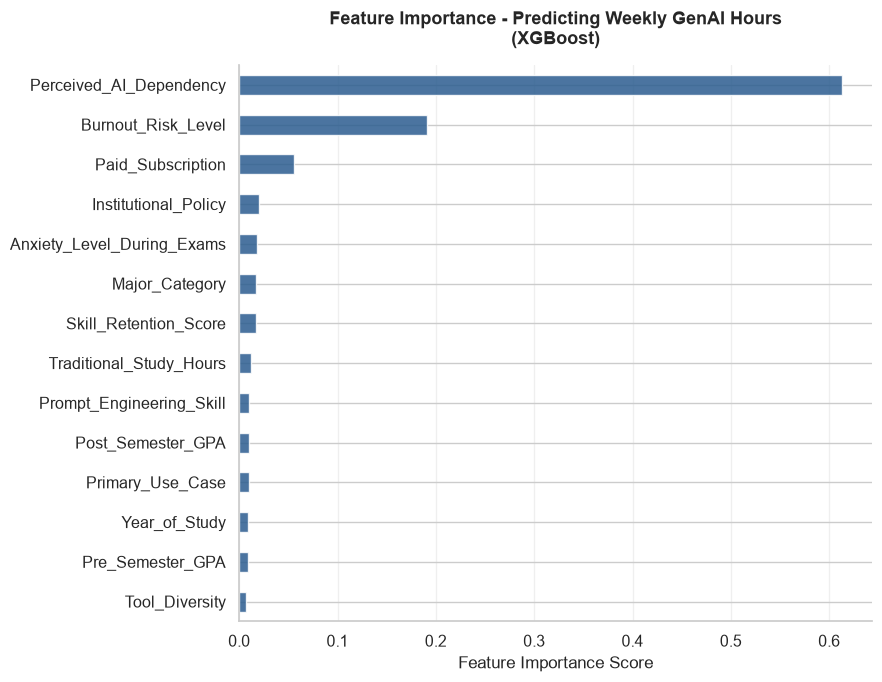

In [172]:
importance = (
    pd.Series(model.feature_importances_, index=X_xgb.columns)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
importance.plot(kind='barh', color=C_PRIMARY, alpha=0.85, ax=ax)
ax.set_title('Feature Importance - Predicting Weekly GenAI Hours\n(XGBoost)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

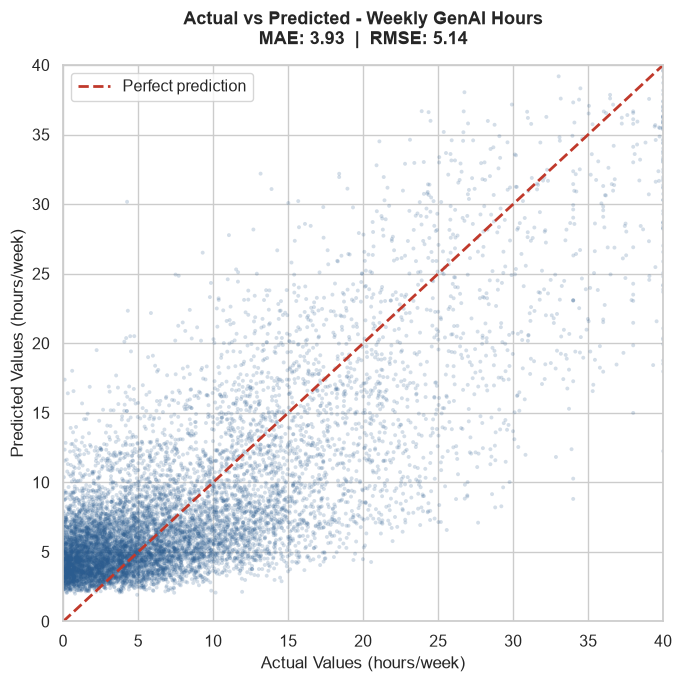

In [173]:
predictions = model.predict(X_test)
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

mn = min(float(y_test.min()), float(predictions.min()))
mx = max(float(y_test.max()), float(predictions.max()))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, predictions, alpha=0.2, color=C_PRIMARY, edgecolor='none', s=8)
ax.plot([mn, mx], [mn, mx], color=C_ACCENT, linestyle='--', linewidth=2,
        label='Perfect prediction')
ax.set_title(
    f'Actual vs Predicted - Weekly GenAI Hours\nMAE: {mae:.2f}  |  RMSE: {rmse:.2f}',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Actual Values (hours/week)')
ax.set_ylabel('Predicted Values (hours/week)')
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [13]:
save_path = 'eda_preprocessed.json'

In [14]:
sampled = df.sample(n=5000, random_state=42)
sampled.to_json(save_path, index=False)

In [15]:
sampled.to_json('public/eda_preprocessed.json', orient='records', indent=2)
